# Tahap 1 - Membangun Case Base
Notebook ini berfungsi untuk mengeksekusi Tahap 1 dari pipeline Case-Based Reasoning (CBR) analisis putusan pengadilan perceraian. Tahapan ini meliputi:
1. Pembuatan Struktur Folder Proyek
2. Ekstraksi teks dari dokumen PDF (Putusan)
3. Pembersihan (Cleaning) dan Pra-Pemrosesan teks
4. Validasi dan Pencatatan Log
5. Penyimpanan hasil ke dataset CSV yang siap untuk NLP/CBR

## 1. Import dan Instalasi Library
Jalankan sel ini untuk menginstal pustaka yang dibutuhkan jika belum ada, dan mengimpor modul yang diperlukan.

In [1]:
# Jika library belum terinstal di lingkungan Anda, hilangkan tanda pagar (#) pada baris di bawah ini untuk menginstal:
!pip install pdfplumber pdfminer.six Sastrawi nltk pandas numpy matplotlib seaborn tqdm

import os
import re
import glob
import pandas as pd
import numpy as np
import pdfplumber
import nltk
from tqdm import tqdm  # Menggunakan tqdm standar agar tidak memicu error jupyter/ipywidgets
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter

# Download NLTK data untuk tokenisasi dan stopwords
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
print("\nSemua library berhasil diimpor!")

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\wongp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



Semua library berhasil diimpor!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Membuat Struktur Folder Project
Sistem ini membutuhkan direktori khusus untuk data mentah (PDF & TXT) dan data hasil pemrosesan.

In [2]:
base_path = "../" # Karena notebook berada di dalam folder notebooks/
directories = [
    "data/raw_pdf",
    "data/raw",
    "data/processed",
    "logs",
    "results"
]

for dir_path in directories:
    full_path = os.path.join(base_path, dir_path)
    os.makedirs(full_path, exist_ok=True)
    print(f"Direktori siap: {full_path}")

Direktori siap: ../data/raw_pdf
Direktori siap: ../data/raw
Direktori siap: ../data/processed
Direktori siap: ../logs
Direktori siap: ../results


## 3 & 4. Membaca dan Konversi PDF ke Plain Text
Modul ini membaca semua file PDF di folder `/data/raw_pdf/`, mengekstrak teksnya dengan `pdfplumber`, dan menyimpannya di `/data/raw/`.

In [3]:
raw_pdf_dir = os.path.join(base_path, "data/raw_pdf")
raw_txt_dir = os.path.join(base_path, "data/raw")

pdf_files = glob.glob(os.path.join(raw_pdf_dir, "*.pdf"))
print(f"Ditemukan {len(pdf_files)} file PDF untuk diproses.\n")

for idx, pdf_path in enumerate(tqdm(pdf_files, desc="Ekstraksi PDF")):
    filename = os.path.basename(pdf_path)
    case_id = f"case_{idx+1:03d}"
    txt_filename = f"{case_id}.txt"
    txt_path = os.path.join(raw_txt_dir, txt_filename)
    
    full_text = ""
    total_pages = 0
    try:
        with pdfplumber.open(pdf_path) as pdf:
            total_pages = len(pdf.pages)
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text += text + "\n"
                    
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(full_text)
            
        print(f"[{case_id}] Sukses: {filename} | Halaman: {total_pages} | Karakter: {len(full_text)}")
    except Exception as e:
        print(f"[{case_id}] GAGAL mengekstrak {filename}: {e}")

Ditemukan 45 file PDF untuk diproses.



Ekstraksi PDF:   2%|▏         | 1/45 [00:02<02:04,  2.82s/it]

[case_001] Sukses: putusan_0003_pdt.g_2011_pa.srl_20260530072648.pdf | Halaman: 23 | Karakter: 56874


Ekstraksi PDF:   4%|▍         | 2/45 [00:06<02:25,  3.38s/it]

[case_002] Sukses: putusan_0007_pdt.g_2013_pa.kp_20260502234406.pdf | Halaman: 17 | Karakter: 54888


...

[case_043] Sukses: putusan_58_pdt.g_2026_pa.sr_20260530064718.pdf | Halaman: 13 | Karakter: 37260


Ekstraksi PDF:  98%|█████████▊| 44/45 [01:33<00:01,  1.48s/it]

[case_044] Sukses: putusan_673_pdt.g_2016_pa.clg_20260530081945.pdf | Halaman: 6 | Karakter: 17196


Ekstraksi PDF: 100%|██████████| 45/45 [01:35<00:00,  2.12s/it]

[case_045] Sukses: putusan_729_pdt.g_2019_pa.tgr_20260530075015.pdf | Halaman: 9 | Karakter: 26873


## 5. Text Cleaning / Preprocessing (DENGAN STEMMING CACHING OPTIMIZED)
Mendefinisikan fungsi NLP untuk pembersihan teks. 

> **Catatan Optimasi Penting:** Stemmer Sastrawi standar berjalan sangat lambat karena harus memeriksa aturan morfologi dan kamus kata demi kata. Di sini kita menggunakan **Caching Stemming** (menyimpan kata yang sudah pernah di-stem ke dalam dictionary cache). Ini akan mempercepat proses preprocessing hingga **10x - 50x lebih cepat** untuk 45 dokumen panjang!

In [4]:
# Inisialisasi Sastrawi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Inisialisasi Cache Dictionary untuk Stemming agar super cepat
stem_cache = {}

# Konfigurasi Stopwords
from nltk.corpus import stopwords
stop_words_id = set(stopwords.words('indonesian'))
custom_stopwords = {
    'pengadilan', 'hakim', 'perkara', 'putusan', 'republik', 'indonesia', 
    'agama', 'mahkamah', 'agung', 'direktori', 'bahwa', 'yang', 'dan', 'di',
    'dari', 'pada', 'untuk', 'dengan', 'ini', 'itu'
}
stop_words_id.update(custom_stopwords)

def clean_text(text):
    # A. Lowercase
    text = text.lower()
    
    # B. Remove Header & Footer (heuristik dokumen hukum)
    text = re.sub(r'direktori putusan mahkamah agung republik indonesia', '', text)
    text = re.sub(r'mahkamah agung republik indonesia', '', text)
    text = re.sub(r'hal\.\s*\d+\s*dari\s*\d+\s*hal\.', '', text) # Hapus nomor halaman berulang
    text = re.sub(r'putusan nomor\s*\S+', '', text) # Hapus nomor putusan berulang jika perlu
    
    # C. Remove URL
    text = re.sub(r'http[s]?://\S+', '', text)
    
    # D & F. Remove Special Character & Punctuation (Hanya pertahankan huruf)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # E. Remove Extra Whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # G. Tokenization
    tokens = nltk.tokenize.word_tokenize(text)
    
    # H. Stopword Removal
    tokens = [w for w in tokens if w not in stop_words_id]
    
    # I. Caching Stemming
    stemmed_tokens = []
    for token in tokens:
        if token not in stem_cache:
            stem_cache[token] = stemmer.stem(token)
        stemmed_tokens.append(stem_cache[token])
        
    return " ".join(stemmed_tokens)

print("Fungsi cleaning teks teroptimasi dengan caching siap!")

Fungsi cleaning teks teroptimasi dengan caching siap!


## 6 & 7 & 8. Validasi, Logging, dan Penyimpanan Hasil Cleaning
Membaca file ekstraksi `.txt`, memprosesnya dengan fungsi `clean_text()`, memvalidasi panjangnya, mencatat log, dan menyimpannya di folder `/data/processed/`.

In [5]:
log_path = os.path.join(base_path, "logs/cleaning.log")
logging.basicConfig(filename=log_path, level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s', force=True)

txt_files = glob.glob(os.path.join(raw_txt_dir, "*.txt"))
processed_dir = os.path.join(base_path, "data/processed")

dataset_records = []

for txt_path in tqdm(txt_files, desc="Cleaning & Validasi"):
    filename = os.path.basename(txt_path)
    case_id = filename.replace('.txt', '')
    
    with open(txt_path, "r", encoding="utf-8") as f:
        raw_text = f.read()
        
    raw_length = len(raw_text)
    
    # Validasi dokumen kosong atau terlalu pendek
    if raw_length < 100:
        msg = f"Teks terlalu pendek ({raw_length} char) untuk {filename}. Kemungkinan PDF rusak."
        logging.warning(msg)
        print(f"\n[WARNING] {msg}")
        continue
        
    clean_txt = clean_text(raw_text)
    clean_length = len(clean_txt)
    
    # Validasi kelengkapan pasca-cleaning (harus ada minimal 20% info penting dari aslinya)
    if clean_length < (0.2 * raw_length):
        msg = f"Kemungkinan informasi penting hilang saat cleaning pada {filename}. Sisa teks: {clean_length}/{raw_length}"
        logging.warning(msg)
        print(f"\n[WARNING] {msg}")
    else:
        logging.info(f"Sukses cleaning {filename}. {raw_length} -> {clean_length} chars.")
        
    # Simpan File Bersih
    clean_filename = f"{case_id}_clean.txt"
    clean_filepath = os.path.join(processed_dir, clean_filename)
    with open(clean_filepath, "w", encoding="utf-8") as f:
        f.write(clean_txt)
        
    dataset_records.append({
        "case_id": case_id,
        "original_text": raw_text,
        "clean_text": clean_txt,
        "text_length": clean_length
    })

print(f"\nProses selesai! Data tersimpan di: {processed_dir}")
print(f"Log pembersihan tersimpan di: {log_path}")

Cleaning & Validasi: 100%|██████████| 45/45 [13:27<00:00, 17.95s/it]


Proses selesai! Data tersimpan di: ../data/processed
Log pembersihan tersimpan di: ../logs/cleaning.log


## 9. Membuat Dataset CSV
Mengonversi metadata dan teks bersih menjadi DataFrame *pandas* lalu mengekspornya ke berkas CSV yang siap pakai untuk Tahap 2.

In [6]:
df_cases = pd.DataFrame(dataset_records)
csv_path = os.path.join(processed_dir, "cases_clean.csv")

if not df_cases.empty:
    df_cases.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"Dataset berhasil disimpan ke {csv_path} dengan total {len(df_cases)} dokumen.")
else:
    print("Dataset kosong, tidak ada data yang bisa disimpan.")

df_cases.head()

Dataset berhasil disimpan ke ../data/processed\cases_clean.csv dengan total 45 dokumen.


,case_id,original_text,clean_text,text_length
0,case_001,a\ni\ns\ne\nn\no\nd\nn\nI\nk\ni\nl\nb\nu\np\ne...,a i s e n o d n i k i l b u p e a r i s g e n ...,31129
1,case_002,a\ni\ns\ne\nn\no\nd\nn\nI\nk\ni\nl\nb\nu\np\ne...,a i s e n o d n i k i l b u p e a r i s g e n ...,29810
2,case_003,a\ni\ns\ne\nn\no\nd\nn\nI\nk\ni\nl\nb\nu\np\ne...,a i s e n o d n i k i l b u p e a r i s g e n ...,13806
3,case_004,a\ni\ns\ne\nn\no\nd\nn\nI\nk\ni\nl\nb\nu\np\ne...,a i s e n o d n i k i l b u p e a r i s g e n ...,27373
4,case_005,a\ni\ns\ne\nn\no\nd\nn\nI\nk\ni\nl\nb\nu\np\ne...,a i s e n o d n i k i l b u p e a r i s g e n ...,21549


## 10 & 11. Analisis Sederhana dan Visualisasi Data
Menampilkan metrik deskriptif dataset yang telah dibuat, seperti sebaran panjang dokumen dan kata-kata (*vocabularies*) yang paling sering muncul.

=== Analisis Dataset ===
Jumlah total dokumen: 45
Rata-rata panjang dokumen bersih: 20230.71 karakter
Jumlah kata unik (Vocabulary): 7052


C:\Users\wongp\AppData\Local\Temp\ipykernel_13336\717997014.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


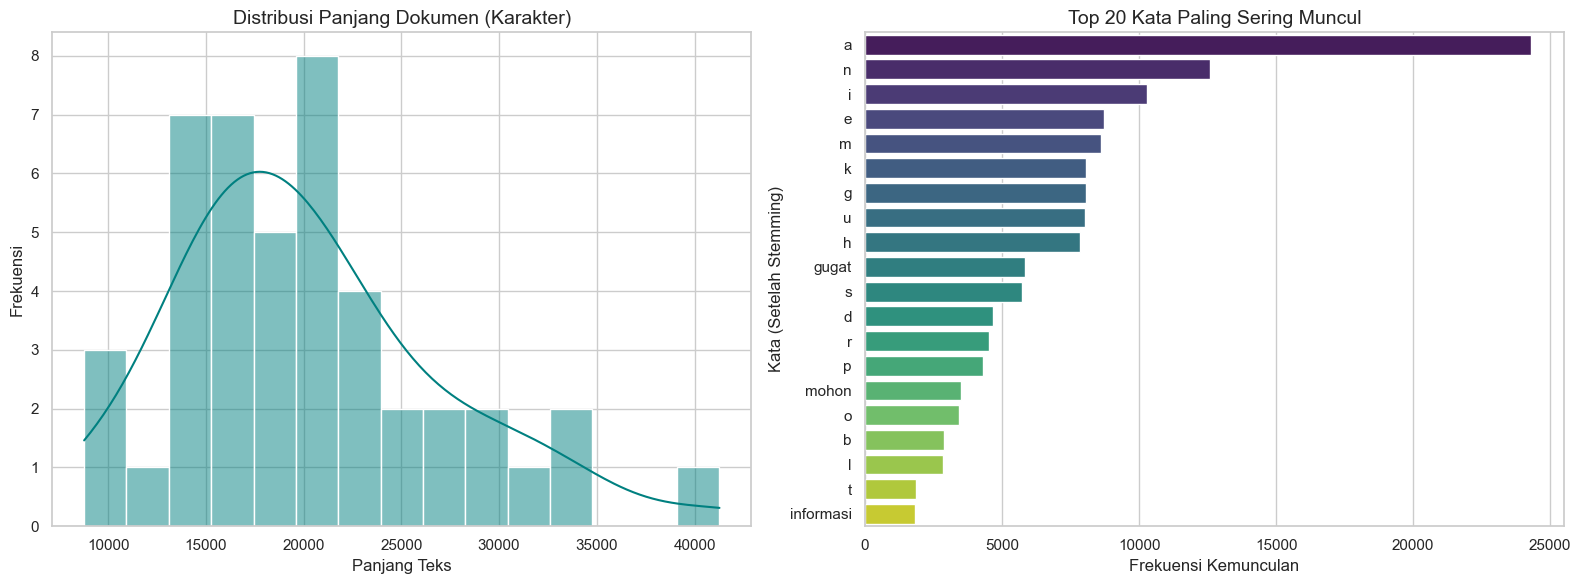

In [7]:
if not df_cases.empty:
    print("=== Analisis Dataset ===")
    print(f"Jumlah total dokumen: {len(df_cases)}")
    print(f"Rata-rata panjang dokumen bersih: {df_cases['text_length'].mean():.2f} karakter")
    
    # Menggabungkan teks untuk mengekstrak frekuensi kata
    all_words = " ".join(df_cases['clean_text'].tolist()).split()
    print(f"Jumlah kata unik (Vocabulary): {len(set(all_words))}")
    
    word_counts = Counter(all_words)
    top_20 = word_counts.most_common(20)
    
    # Pengaturan Visualisasi (Seaborn & Matplotlib)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 6))
    
    # Plot Distribusi Panjang Dokumen
    plt.subplot(1, 2, 1)
    sns.histplot(df_cases['text_length'], bins=15, kde=True, color='teal')
    plt.title("Distribusi Panjang Dokumen (Karakter)", fontsize=14)
    plt.xlabel("Panjang Teks")
    plt.ylabel("Frekuensi")
    
    # Plot Top 20 Kata
    plt.subplot(1, 2, 2)
    words, counts = zip(*top_20)
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title("Top 20 Kata Paling Sering Muncul", fontsize=14)
    plt.xlabel("Frekuensi Kemunculan")
    plt.ylabel("Kata (Setelah Stemming)")
    
    plt.tight_layout()
    plt.show()
else:
    print("Dataset kosong. Pastikan proses cleaning berjalan dengan benar.")